# MNIST Classification with Support Vector Machines

## Task Overview

This notebook completes the required MNIST SVM lab:

- load the MNIST handwritten digit dataset from `tensorflow.keras.datasets`,
- use the provided training and test split,
- flatten each `28 x 28` grayscale image into a feature vector,
- normalize pixel intensities with NumPy,
- reduce the training set to `10,000` examples while preserving class balance,
- compare soft-margin and harder-margin SVM settings,
- make experimental runs across kernel functions and preprocessing choices,
- apply stratified cross validation,
- visualize the confusion matrix for the best model, and
- print the final test accuracy.

The notebook keeps the official MNIST test set unchanged so that the final evaluation remains meaningful.


## Imports

The workflow uses TensorFlow only for loading the MNIST data. The modeling itself is completed with scikit-learn.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist

from sklearn.base import clone
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from sklearn.svm import SVC

pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid")


## Load MNIST and Inspect the Original Split

`mnist.load_data()` already returns a training set and a test set, so we use that split directly.


In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Original training set shape:", x_train.shape, y_train.shape)
print("Original test set shape:", x_test.shape, y_test.shape)

train_distribution = pd.Series(y_train).value_counts().sort_index()
test_distribution = pd.Series(y_test).value_counts().sort_index()

display(
    pd.DataFrame(
        {
            "train_count": train_distribution,
            "test_count": test_distribution,
        }
    )
)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original training set shape: (60000, 28, 28) (60000,)
Original test set shape: (10000, 28, 28) (10000,)


,train_count,test_count
0,5923,980
1,6742,1135
2,5958,1032
3,6131,1010
4,5842,982
5,5421,892
6,5918,958
7,6265,1028
8,5851,974
9,5949,1009


## Flatten and Normalize the Images

Each image is reshaped from `28 x 28` into a vector of length `784`.  
Normalization is done with NumPy by converting to `float32` and dividing by `255.0`.


In [3]:
x_train_flat = x_train.reshape(x_train.shape[0], -1).astype(np.float32)
x_test_flat = x_test.reshape(x_test.shape[0], -1).astype(np.float32)

x_train_flat = np.divide(x_train_flat, 255.0)
x_test_flat = np.divide(x_test_flat, 255.0)

print("Flattened training shape:", x_train_flat.shape)
print("Flattened test shape:", x_test_flat.shape)
print("Pixel range after normalization:", x_train_flat.min(), "to", x_train_flat.max())


Flattened training shape: (60000, 784)
Flattened test shape: (10000, 784)
Pixel range after normalization: 0.0 to 1.0


## Reduce the Training Set to 10,000 Balanced Samples

To keep SVM training computationally manageable, the training set is reduced to exactly `10,000` images while preserving class balance.  
Because MNIST has ten classes, this notebook samples `1,000` images per digit.


In [4]:
def balanced_sample(features, labels, samples_per_class=1000, random_state=42):
    rng = np.random.default_rng(random_state)
    selected_indices = []

    for class_label in np.unique(labels):
        class_indices = np.where(labels == class_label)[0]
        chosen = rng.choice(class_indices, size=samples_per_class, replace=False)
        selected_indices.extend(chosen.tolist())

    selected_indices = np.array(selected_indices)
    rng.shuffle(selected_indices)
    return features[selected_indices], labels[selected_indices]


x_train_balanced, y_train_balanced = balanced_sample(
    x_train_flat,
    y_train,
    samples_per_class=1000,
    random_state=42,
)

print("Balanced training subset shape:", x_train_balanced.shape)
display(pd.Series(y_train_balanced).value_counts().sort_index().rename("count").to_frame())


Balanced training subset shape: (10000, 784)


,count
0,1000
1,1000
2,1000
3,1000
4,1000
5,1000
6,1000
7,1000
8,1000
9,1000


## Cross Validation Setup

Stratified 5-fold cross validation keeps the class proportions stable in each fold.


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


## Soft Margin vs Harder Margin Comparison

For SVM, a larger `C` means a harder margin with less tolerance for misclassification.  
The comparison below keeps the kernel fixed to `linear` so the impact of the margin parameter is easier to see.


In [6]:
margin_models = {
    "soft_margin_linear_C1": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("svc", SVC(kernel="linear", C=1)),
        ]
    ),
    "harder_margin_linear_C100": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("svc", SVC(kernel="linear", C=100)),
        ]
    ),
}

margin_rows = []
for model_name, model in margin_models.items():
    cv_result = cross_validate(
        model,
        x_train_balanced,
        y_train_balanced,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
        return_train_score=True,
    )
    margin_rows.append(
        {
            "model": model_name,
            "mean_train_accuracy": cv_result["train_score"].mean(),
            "mean_validation_accuracy": cv_result["test_score"].mean(),
            "std_validation_accuracy": cv_result["test_score"].std(),
        }
    )

margin_results = pd.DataFrame(margin_rows).sort_values(
    by="mean_validation_accuracy",
    ascending=False,
)
display(margin_results)


,model,mean_train_accuracy,mean_validation_accuracy,std_validation_accuracy
0,soft_margin_linear_C1,1.0,0.9057,0.0072
1,harder_margin_linear_C100,1.0,0.9057,0.0072


## Kernel and Preprocessing Search

This grid search explores:

- `linear`, `rbf`, and `poly` kernels,
- softer and harder margin settings through different `C` values,
- multiple scaling choices (`passthrough`, `StandardScaler`, `MinMaxScaler`, `RobustScaler`),
- and kernel-specific parameters such as `gamma` and polynomial degree.

The best model is selected using cross-validated accuracy.


In [ ]:
pipeline = Pipeline(
    [
        ("scaler", "passthrough"),
        ("svc", SVC()),
    ]
)

param_grid = [
    {
        "scaler": ["passthrough", StandardScaler(), MinMaxScaler(), RobustScaler()],
        "svc__kernel": ["linear"],
        "svc__C": [0.1, 1, 10, 100],
    },
    {
        "scaler": ["passthrough", StandardScaler(), MinMaxScaler(), RobustScaler()],
        "svc__kernel": ["rbf"],
        "svc__C": [1, 10, 100],
        "svc__gamma": ["scale", 0.01, 0.001],
    },
    {
        "scaler": ["passthrough", StandardScaler(), MinMaxScaler()],
        "svc__kernel": ["poly"],
        "svc__C": [1, 10],
        "svc__degree": [2, 3],
        "svc__gamma": ["scale"],
    },
]

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
)

grid_search.fit(x_train_balanced, y_train_balanced)

print("Best cross-validation accuracy:", round(grid_search.best_score_, 4))
print("Best parameters:")
print(grid_search.best_params_)


Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best cross-validation accuracy: 0.9621
Best parameters:
{'scaler': 'passthrough', 'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}


## Review the Best Experimental Runs


In [ ]:
cv_results = pd.DataFrame(grid_search.cv_results_)

result_columns = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "param_scaler",
    "param_svc__kernel",
    "param_svc__C",
    "param_svc__gamma",
    "param_svc__degree",
]

top_runs = (
    cv_results[result_columns]
    .sort_values(by=["rank_test_score", "mean_test_score"], ascending=[True, False])
    .head(10)
    .reset_index(drop=True)
)

display(top_runs)


,rank_test_score,mean_test_score,std_test_score,param_scaler,param_svc__kernel,param_svc__C,param_svc__gamma,param_svc__degree
0,1,0.9621,0.0046,passthrough,rbf,10.0,scale,NaN
1,1,0.9621,0.0046,passthrough,rbf,100.0,scale,NaN
2,1,0.9621,0.0046,MinMaxScaler(),rbf,10.0,scale,NaN
3,1,0.9621,0.0046,MinMaxScaler(),rbf,100.0,scale,NaN
4,5,0.9593,0.0053,passthrough,rbf,100.0,0.01,NaN
5,6,0.9591,0.0055,passthrough,rbf,10.0,0.01,NaN
6,6,0.9591,0.0054,MinMaxScaler(),rbf,100.0,0.01,NaN
7,8,0.9590,0.0056,MinMaxScaler(),rbf,10.0,0.01,NaN
8,9,0.9569,0.0054,passthrough,poly,10.0,scale,2.0
9,10,0.9568,0.0054,MinMaxScaler(),poly,10.0,scale,2.0


## Fit the Best Model and Evaluate on the Test Set


In [ ]:
best_model = clone(grid_search.best_estimator_)
best_model.fit(x_train_balanced, y_train_balanced)

y_pred = best_model.predict(x_test_flat)
test_accuracy = accuracy_score(y_test, y_pred)

print("Final test accuracy:", round(test_accuracy, 4))
print()
print("Classification report:")
print(classification_report(y_test, y_pred))


Final test accuracy: 0.9705

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.97      0.96      1010
           4       0.96      0.98      0.97       982
           5       0.96      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.97      0.96      0.96       974
           9       0.97      0.94      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



## Confusion Matrix


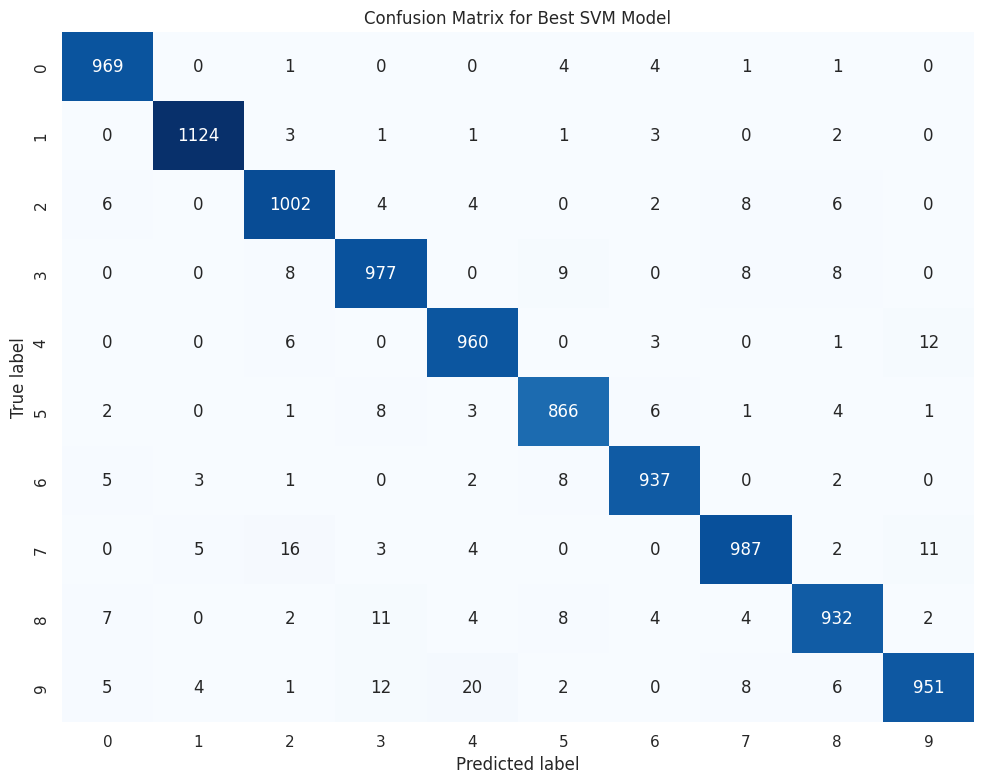

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix for Best SVM Model")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


## Short Conclusion

After running the notebook, use the final outputs to discuss:

1. whether the harder margin (`larger C`) helped or hurt validation accuracy,
2. which kernel produced the best cross-validated performance,
3. whether scaling changed the result materially, and
4. the final test accuracy and the main error patterns visible in the confusion matrix.

On MNIST, the `rbf` kernel often performs very strongly, but the notebook is set up to confirm that experimentally rather than assume it.
